# Analyse des performances du système RAG

Ce notebook présente et analyse les résultats obtenus lors de l'évaluation du système RAG de recommandation d'événements.

Deux approches complémentaires sont utilisées :

- **Évaluation sur un jeu de questions annoté** : vérification de la capacité du système à répondre correctement à différents cas d'usage représentatifs.
- **Évaluation Ragas** : mesure automatique de la qualité du système, notamment de la fidélité des réponses au contexte (*Faithfulness*) et de la pertinence des documents récupérés (*Context Precision*).

L'objectif est d'identifier les points forts du système, ses limites et les pistes d'amélioration possibles.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ragas_results = pd.read_csv("results/ragas_results.csv")
annotated_results = pd.read_csv("results/annotated_results.csv")

print("Ragas :", ragas_results.shape)
print("Évaluation annotée :", annotated_results.shape)

Ragas : (7, 4)
Évaluation annotée : (7, 4)


In [11]:
print("Colonnes Ragas :")
print(ragas_results.columns.tolist())

print("\nColonnes évaluation annotée :")
print(annotated_results.columns.tolist())

Colonnes Ragas :
['question', 'answer', 'faithfulness', 'context_precision']

Colonnes évaluation annotée :
['question', 'expected_answer', 'generated_answer', 'human_label']


In [12]:
display(ragas_results.head())

,question,answer,faithfulness,context_precision
0,Quels concerts de jazz sont prévus en 2026 ?,Voici les concerts de jazz prévus en 2026 à To...,0.900000,0.333333
1,Quelles activités créatives sont prévues en No...,Voici les activités créatives prévues en **nov...,0.827586,0.000000
2,Quelle est la prochaine date de Symphony on Ti...,La prochaine date de **Symphony on Titan** est...,1.000000,1.000000
3,Quelles activités sont adaptées aux enfants de...,Voici les activités adaptées aux enfants de 3 ...,0.600000,0.804167
4,Comment puis-je réserver des billets pour Moza...,"Pour réserver des billets pour **""Mozart par L...",1.000000,1.000000


In [13]:
display(annotated_results.head())

,question,expected_answer,generated_answer,human_label
0,Quels concerts de jazz sont prévus en 2026 ?,['La réponse propose uniquement des événements...,Voici les concerts de jazz prévus en 2026 à To...,correcte
1,Quelles activités créatives sont prévues en No...,['La réponse propose uniquement des événements...,Voici les activités créatives prévues en **nov...,partiellement correcte
2,Quelle est la prochaine date de Symphony on Ti...,"[""La réponse concerne bien l'événement Symphon...",La prochaine date pour **Symphony on Titan** e...,correcte
3,Quelles activités sont adaptées aux enfants de...,['La réponse propose au moins une activité don...,Voici les activités adaptées aux enfants de 3 ...,correcte
4,Comment puis-je réserver des billets pour Moza...,"[""La réponse concerne bien l'événement Mozart ...","Pour réserver des billets pour **""Mozart par L...",correcte


### Description des données d'évaluation

Les deux fichiers d'évaluation contiennent chacun **7 observations et 4 variables** (`7 × 4`). Ils correspondent aux mêmes 7 questions de test, mais évaluent les performances du système RAG selon deux approches complémentaires.

**Résultats Ragas (`ragas_results.csv`)**

Ce fichier contient les résultats de l'évaluation automatique réalisée avec Ragas :

- `question` : question soumise au système RAG ;
- `answer` : réponse générée par le système ;
- `faithfulness` : mesure dans quelle mesure la réponse générée est fidèle aux informations présentes dans le contexte récupéré ;
- `context_precision` : mesure la pertinence des éléments récupérés par le système par rapport à la question.

Les deux métriques sont exprimées sous forme de scores numériques, ce qui permet d'analyser quantitativement les performances du système.

**Évaluation annotée (`annotated_results.csv`)**

Ce fichier contient l'évaluation manuelle des réponses :

- `question` : question soumise au système ;
- `expected_answer` : critères définissant ce qui est attendu d'une réponse satisfaisante ;
- `generated_answer` : réponse effectivement produite par le système RAG ;
- `human_label` : appréciation manuelle de la réponse selon trois catégories : `correcte`, `partiellement correcte` ou `incorrecte`.

Cette seconde évaluation apporte une appréciation qualitative permettant de vérifier si les réponses répondent réellement aux attentes définies pour chaque cas d'usage.

Les deux approches sont donc complémentaires : **Ragas fournit une évaluation automatique et quantitative du fonctionnement du RAG, tandis que l'annotation humaine permet d'évaluer qualitativement la pertinence des réponses par rapport aux attentes métier.**

## 1. Analyse de l'évaluation humaine

L'évaluation humaine permet de mesurer directement la qualité des réponses du système par rapport aux critères définis pour chaque question de test.

Les réponses sont réparties en trois catégories :

- **Correcte** : la réponse satisfait les critères attendus ;
- **Partiellement correcte** : la réponse est globalement pertinente mais présente certaines limites ;
- **Incorrecte** : la réponse ne répond pas suffisamment aux critères définis.

L'objectif est d'observer la proportion de réponses satisfaisantes, mais également d'identifier les types de requêtes pour lesquels le système rencontre davantage de difficultés.

In [14]:
human_counts = annotated_results["human_label"].value_counts()
human_percentages = (
    annotated_results["human_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

human_summary = pd.DataFrame({
    "Nombre de réponses": human_counts,
    "Pourcentage (%)": human_percentages
})

display(human_summary)

,Nombre de réponses,Pourcentage (%)
human_label,,
correcte,6,85.7
partiellement correcte,1,14.3


In [15]:
display(
    annotated_results[
        ["question", "human_label"]
    ]
)

,question,human_label
0,Quels concerts de jazz sont prévus en 2026 ?,correcte
1,Quelles activités créatives sont prévues en No...,partiellement correcte
2,Quelle est la prochaine date de Symphony on Ti...,correcte
3,Quelles activités sont adaptées aux enfants de...,correcte
4,Comment puis-je réserver des billets pour Moza...,correcte
5,Quelles expositions sont accessibles aux perso...,correcte
6,Il y a une exposition à Paris en Décembre,correcte


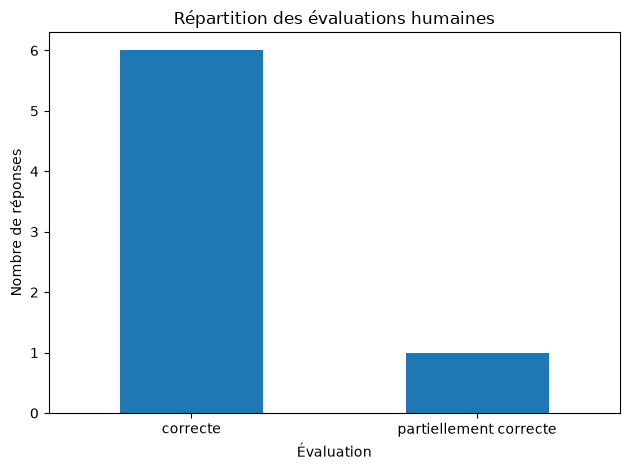

In [16]:
human_counts.plot(kind="bar")

plt.title("Répartition des évaluations humaines")
plt.xlabel("Évaluation")
plt.ylabel("Nombre de réponses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interprétation

L'évaluation humaine montre une performance globalement satisfaisante du système RAG.

Sur les **7 questions évaluées**, **6 réponses (85,7 %)** sont considérées comme correctes et **1 réponse (14,3 %)** comme partiellement correcte. Aucune réponse n'a été classée comme incorrecte.

Ces résultats indiquent que, dans la majorité des cas testés, le système est capable de produire une réponse conforme aux critères attendus : respect du type d'événement recherché, des contraintes formulées par l'utilisateur et des informations présentes dans les données sources.

La présence d'une réponse partiellement correcte montre néanmoins que certaines requêtes peuvent encore mettre en évidence des limites du système. L'analyse de cette réponse permettra d'identifier plus précisément l'origine de cette difficulté et les pistes d'amélioration possibles.

Compte tenu du nombre limité de questions évaluées, ces résultats doivent être interprétés comme une validation du fonctionnement du POC plutôt que comme une mesure exhaustive de ses performances.

In [18]:
correct_results = annotated_results[
    annotated_results["human_label"] == "correcte"
]

display(
    correct_results[
        ["question", "expected_answer", "generated_answer"]
    ]
)

,question,expected_answer,generated_answer
0,Quels concerts de jazz sont prévus en 2026 ?,['La réponse propose uniquement des événements...,Voici les concerts de jazz prévus en 2026 à To...
2,Quelle est la prochaine date de Symphony on Ti...,"[""La réponse concerne bien l'événement Symphon...",La prochaine date pour **Symphony on Titan** e...
3,Quelles activités sont adaptées aux enfants de...,['La réponse propose au moins une activité don...,Voici les activités adaptées aux enfants de 3 ...
4,Comment puis-je réserver des billets pour Moza...,"[""La réponse concerne bien l'événement Mozart ...","Pour réserver des billets pour **""Mozart par L..."
5,Quelles expositions sont accessibles aux perso...,['La réponse propose uniquement des événements...,Voici les expositions accessibles aux personne...
6,Il y a une exposition à Paris en Décembre,['La réponse doit reconnaître que la base de c...,Aucun événement correspondant à une exposition...


### Analyse des réponses correctes

Les six réponses classées comme correctes couvrent des cas d'usage variés et permettent d'observer plusieurs capacités du système.

Le système parvient tout d'abord à traiter des **recherches thématiques associées à une contrainte temporelle**, comme la recherche de concerts de jazz en 2026. Les événements proposés correspondent au thème demandé et sont accompagnés de leurs dates et lieux.

Les questions portant sur un **événement précisément identifié** obtiennent également de bons résultats. Pour *Symphony on Titan*, le système fournit directement la prochaine date disponible. Pour *Mozart par Les Musiciens du Louvre*, il restitue les différentes modalités de réservation disponibles dans les données.

Le système est également capable d'exploiter certaines **contraintes liées au public**. Dans la recherche d'activités pour les enfants de 3 à 6 ans, il distingue notamment une activité destinée aux 4-7 ans et précise que celle-ci ne couvre qu'une partie de la tranche d'âge recherchée.

La recherche concernant les **personnes à mobilité réduite** montre également un comportement pertinent : le système s'appuie sur les informations d'accessibilité présentes dans les données et signale lorsqu'une information d'accessibilité n'est pas disponible, plutôt que de supposer qu'un événement est accessible.

Enfin, la requête concernant une exposition à Paris permet de tester le comportement du système face à une **demande hors du périmètre géographique de la base de connaissances**. Le système n'invente pas d'événement et indique qu'aucun événement correspondant n'est disponible dans le contexte fourni.

Ces différents résultats montrent que le système est capable d'exploiter plusieurs types d'informations présentes dans la base vectorielle : thématique, date, public cible, accessibilité, modalités de réservation et localisation.

In [17]:
partial_results = annotated_results[
    annotated_results["human_label"] == "partiellement correcte"
]

display(
    partial_results[
        ["question", "expected_answer", "generated_answer"]
    ]
)

,question,expected_answer,generated_answer
1,Quelles activités créatives sont prévues en No...,['La réponse propose uniquement des événements...,Voici les activités créatives prévues en **nov...


### Analyse du cas partiellement correct

La seule réponse classée comme **partiellement correcte** concerne la recherche d'activités créatives prévues en novembre 2026.

Le système identifie correctement des événements à caractère créatif, notamment des expositions et des ateliers. Cependant, les événements proposés ont lieu en **novembre 2025**, alors que la requête porte explicitement sur **novembre 2026**.

La réponse tente de justifier leur présence en indiquant que les événements sont « toujours visibles en 2026 ». Or, la présence d'un événement dans la base de connaissances ne signifie pas qu'il se déroule pendant la période demandée.

Ce cas met en évidence une limite importante d'une recherche reposant principalement sur la similarité sémantique : le système comprend correctement le thème recherché (« activités créatives »), mais le respect d'une contrainte structurée telle qu'une date n'est pas garanti.

Une piste d'amélioration serait de combiner la recherche vectorielle avec des **filtres structurés sur les dates**, afin d'exclure avant la génération les événements ne correspondant pas à la période demandée.

## 2. Évaluation automatique avec Ragas

L'évaluation Ragas complète l'évaluation humaine en mesurant automatiquement deux dimensions du système RAG :

- **Faithfulness** : mesure dans quelle mesure la réponse générée reste fidèle aux informations contenues dans le contexte récupéré ;
- **Context Precision** : mesure la pertinence des éléments du contexte récupéré par rapport à la question posée.

Ces métriques permettent d'évaluer séparément la qualité de la génération et la qualité du retrieval.

In [19]:
ragas_summary = pd.DataFrame({
    "Métrique": ["Faithfulness", "Context Precision"],
    "Score moyen": [
        ragas_results["faithfulness"].mean(),
        ragas_results["context_precision"].mean()
    ]
})

ragas_summary["Score moyen"] = ragas_summary["Score moyen"].round(3)

display(ragas_summary)

,Métrique,Score moyen
0,Faithfulness,0.827
1,Context Precision,0.688


In [22]:
display(
    ragas_results[
        ["question", "faithfulness", "context_precision"]
    ]
)

,question,faithfulness,context_precision
0,Quels concerts de jazz sont prévus en 2026 ?,0.900000,0.333333
1,Quelles activités créatives sont prévues en No...,0.827586,0.000000
2,Quelle est la prochaine date de Symphony on Ti...,1.000000,1.000000
3,Quelles activités sont adaptées aux enfants de...,0.600000,0.804167
4,Comment puis-je réserver des billets pour Moza...,1.000000,1.000000
5,Quelles expositions sont accessibles aux perso...,0.964286,0.679167
6,Il y a une exposition à Paris en Décembre,0.500000,1.000000


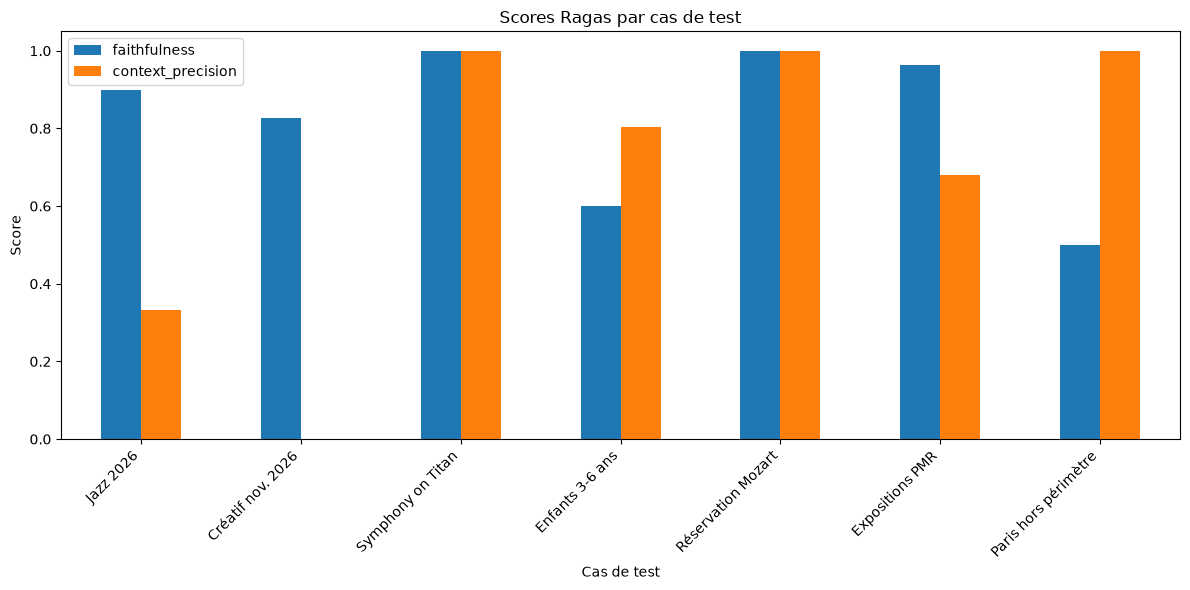

In [ ]:
ragas_plot = ragas_results[
    ["faithfulness", "context_precision"]
].copy()

ragas_plot["cas_test"] = [
    "Jazz 2026",
    "Créatif nov. 2026",
    "Symphony on Titan",
    "Enfants 3-6 ans",
    "Réservation Mozart",
    "Expositions PMR",
    "Paris hors périmètre"
]

ragas_plot = ragas_plot.set_index("cas_test")

ragas_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#6C5CE7", "#B8B5FF"]
)

plt.title("Scores Ragas par cas de test")
plt.xlabel("Cas de test")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Interprétation globale des résultats Ragas

Les résultats Ragas montrent une **Faithfulness moyenne de 0,827** et une **Context Precision moyenne de 0,688**.

La Faithfulness relativement élevée indique que les réponses générées restent globalement fidèles aux informations récupérées dans la base de connaissances. Le modèle génère donc peu d'informations totalement détachées du contexte fourni.

La Context Precision est plus faible et surtout plus variable selon les questions. Cela suggère que la principale marge d'amélioration du système se situe davantage au niveau du **retrieval** que de la génération : certains documents récupérés par FAISS ne correspondent pas suffisamment aux contraintes précises de la requête.

Les résultats par question montrent toutefois des différences importantes. Il est donc nécessaire d'analyser les cas individuellement plutôt que de se limiter aux scores moyens.

#### Requêtes portant sur un événement précis

Les deux meilleurs résultats concernent des requêtes portant sur un événement explicitement identifié :

- *Quelle est la prochaine date de Symphony on Titan ?*
- *Comment puis-je réserver des billets pour Mozart par Les Musiciens du Louvre ?*

Ces deux requêtes obtiennent un score de **1,0 en Faithfulness et en Context Precision**.

Lorsque l'utilisateur fournit le nom précis d'un événement, la recherche vectorielle parvient donc à récupérer un contexte particulièrement pertinent. Le LLM peut ensuite extraire l'information demandée (date ou modalités de réservation) sans introduire d'information non soutenue par le contexte.

Ces résultats montrent que le système est particulièrement performant pour les recherches factuelles portant sur un événement identifié.

#### Requêtes de recommandation avec contraintes

Les requêtes plus ouvertes présentent des résultats plus contrastés.

La recherche de concerts de jazz obtient une **Faithfulness élevée (0,90)** mais une **Context Precision faible (0,333)**. La réponse générée reste donc largement cohérente avec le contexte, mais une partie des documents récupérés est considérée comme peu pertinente pour répondre précisément à la demande.

La recherche d'expositions accessibles aux personnes à mobilité réduite présente un comportement similaire mais moins marqué : la Faithfulness atteint **0,964**, contre **0,679** pour la Context Precision.

À l'inverse, la recherche d'activités adaptées aux enfants de 3 à 6 ans obtient une Context Precision relativement élevée (**0,804**) mais une Faithfulness plus faible (**0,60**).

Ces résultats montrent que les requêtes combinant plusieurs contraintes (thématique, date, âge, accessibilité...) sont plus difficiles à traiter que les recherches portant sur un événement précisément identifié.

#### Limite liée aux contraintes temporelles

La requête concernant les activités créatives en novembre 2026 constitue le cas le plus révélateur d'une faiblesse du retrieval.

La **Context Precision est de 0**, alors que la Faithfulness reste relativement élevée (**0,828**). L'analyse humaine de cette même réponse avait montré que le système récupérait bien des activités créatives, mais que celles-ci avaient lieu en novembre 2025 et non en novembre 2026.

Les deux méthodes d'évaluation convergent donc sur ce cas : le système identifie correctement la thématique recherchée mais ne respecte pas suffisamment la contrainte temporelle.

Cette observation suggère que la similarité vectorielle seule n'est pas toujours suffisante pour traiter des contraintes structurées telles que les dates. L'ajout d'un filtrage temporel avant ou après la recherche vectorielle constitue une piste d'amélioration importante.

#### Cas particulier : requête hors périmètre

La requête concernant une exposition à Paris présente un résultat particulier : la **Context Precision atteint 1,0**, tandis que la Faithfulness n'est que de **0,50**.

L'évaluation humaine considère pourtant la réponse comme correcte : le système reconnaît que les événements récupérés concernent Toulouse et ne tente pas d'inventer une exposition parisienne.

Cette différence montre l'intérêt de compléter les métriques automatiques par une évaluation humaine. Un score Ragas plus faible ne signifie pas nécessairement que la réponse est inutilisable ou incorrecte du point de vue de l'utilisateur. Les situations de refus ou de demande hors périmètre peuvent notamment être plus difficiles à représenter par une métrique automatique.

L'utilisation conjointe des deux méthodes permet ainsi d'obtenir une évaluation plus nuancée du comportement du système.

## 3. Comparaison entre l'évaluation humaine et Ragas

L'évaluation humaine et Ragas évaluent le système selon des approches différentes. L'objectif de cette section est de comparer leurs résultats afin de déterminer si les métriques automatiques reflètent également la qualité perçue des réponses.

L'évaluation humaine porte directement sur le respect des critères définis pour chaque cas d'usage, tandis que Ragas analyse plus spécifiquement la fidélité de la génération au contexte (*Faithfulness*) et la pertinence des informations récupérées (*Context Precision*).

In [23]:
comparison = annotated_results[
    ["question", "human_label"]
].merge(
    ragas_results[
        ["question", "faithfulness", "context_precision"]
    ],
    on="question",
    how="inner"
)

display(comparison)

,question,human_label,faithfulness,context_precision
0,Quels concerts de jazz sont prévus en 2026 ?,correcte,0.900000,0.333333
1,Quelles activités créatives sont prévues en No...,partiellement correcte,0.827586,0.000000
2,Quelle est la prochaine date de Symphony on Ti...,correcte,1.000000,1.000000
3,Quelles activités sont adaptées aux enfants de...,correcte,0.600000,0.804167
4,Comment puis-je réserver des billets pour Moza...,correcte,1.000000,1.000000
5,Quelles expositions sont accessibles aux perso...,correcte,0.964286,0.679167
6,Il y a une exposition à Paris en Décembre,correcte,0.500000,1.000000


In [24]:
comparison["cas_test"] = [
    "Jazz 2026",
    "Créatif nov. 2026",
    "Symphony on Titan",
    "Enfants 3-6 ans",
    "Réservation Mozart",
    "Expositions PMR",
    "Paris hors périmètre"
]

display(
    comparison[
        ["cas_test", "human_label", "faithfulness", "context_precision"]
    ]
)

,cas_test,human_label,faithfulness,context_precision
0,Jazz 2026,correcte,0.900000,0.333333
1,Créatif nov. 2026,partiellement correcte,0.827586,0.000000
2,Symphony on Titan,correcte,1.000000,1.000000
3,Enfants 3-6 ans,correcte,0.600000,0.804167
4,Réservation Mozart,correcte,1.000000,1.000000
5,Expositions PMR,correcte,0.964286,0.679167
6,Paris hors périmètre,correcte,0.500000,1.000000


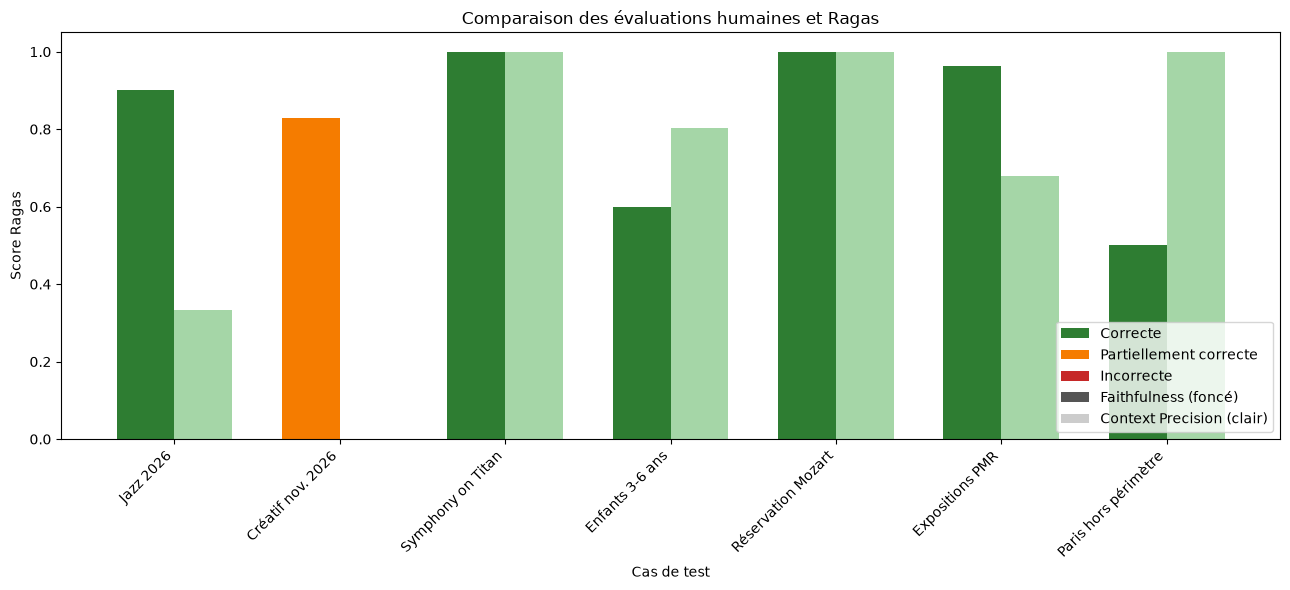

In [31]:
# Couleurs selon l'évaluation humaine
colors = {
    "correcte": ("#2E7D32", "#A5D6A7"),               # vert foncé / clair
    "partiellement correcte": ("#F57C00", "#FFCC80"), # orange foncé / clair
    "incorrecte": ("#C62828", "#EF9A9A")              # rouge foncé / clair
}

x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

for i, row in comparison.reset_index(drop=True).iterrows():
    dark, light = colors[row["human_label"]]

    # Faithfulness = teinte foncée
    ax.bar(
        x[i] - width / 2,
        row["faithfulness"],
        width,
        color=dark
    )

    # Context Precision = teinte claire
    ax.bar(
        x[i] + width / 2,
        row["context_precision"],
        width,
        color=light
    )

ax.set_title("Comparaison des évaluations humaines et Ragas")
ax.set_xlabel("Cas de test")
ax.set_ylabel("Score Ragas")
ax.set_ylim(0, 1.05)

ax.set_xticks(x)
ax.set_xticklabels(
    comparison["cas_test"],
    rotation=45,
    ha="right"
)


legend_elements = [
    Patch(facecolor="#2E7D32", label="Correcte"),
    Patch(facecolor="#F57C00", label="Partiellement correcte"),
    Patch(facecolor="#C62828", label="Incorrecte"),
    Patch(facecolor="#555555", label="Faithfulness (foncé)"),
    Patch(facecolor="#CCCCCC", label="Context Precision (clair)")
]

ax.legend(handles=legend_elements, loc="lower right")


plt.tight_layout()
plt.show()

### Interprétation croisée

La comparaison montre une **convergence partielle entre l'évaluation humaine et les métriques Ragas**, tout en mettant en évidence la complémentarité des deux approches.

Le cas le plus significatif concerne la recherche d'activités créatives en novembre 2026. Il s'agit de la seule réponse classée comme **partiellement correcte** lors de l'évaluation humaine et également de la seule requête obtenant une **Context Precision de 0**. L'analyse qualitative avait montré que les événements récupérés correspondaient à la thématique créative mais pas à l'année demandée. Ragas permet donc ici de détecter une faiblesse du retrieval également identifiée lors de l'évaluation humaine.

Les requêtes concernant *Symphony on Titan* et *Mozart par Les Musiciens du Louvre* présentent également une convergence forte : elles sont jugées correctes manuellement et obtiennent des scores parfaits de **1,0** pour les deux métriques Ragas. Ces résultats confirment la bonne performance du système lorsqu'un événement précis est explicitement identifié dans la requête.

Cependant, une réponse jugée correcte par l'évaluation humaine n'obtient pas nécessairement des scores Ragas parfaits. La recherche de concerts de jazz est par exemple considérée comme correcte malgré une Context Precision de **0,333**, tandis que la requête concernant Paris est correctement gérée par le système mais n'obtient qu'une Faithfulness de **0,50**.

Ces écarts s'expliquent par le fait que les deux méthodes ne mesurent pas exactement la même chose. Ragas évalue certaines propriétés techniques du pipeline RAG, notamment la qualité du contexte récupéré et l'ancrage de la réponse dans celui-ci, alors que l'évaluation humaine juge directement si la réponse satisfait les critères définis pour le cas d'usage.

Les deux méthodes doivent donc être considérées comme **complémentaires plutôt qu'interchangeables**. L'évaluation Ragas permet d'identifier des faiblesses techniques du retrieval ou de la génération, tandis que l'évaluation humaine permet de déterminer si ces faiblesses ont réellement un impact sur la qualité de la réponse du point de vue de l'utilisateur.